cap8_ml_bvrp_oos.ipynb


In [5]:
from pathlib import Path

print("Notebook está rodando em:")
print(Path(".").resolve())

print("\nConteúdo da pasta atual:")
for p in Path(".").iterdir():
    print(" -", p)


Notebook está rodando em:
C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\dissertacao_bitcoin_vrp_ml\cap8_ml

Conteúdo da pasta atual:
 - cap8_ml_bvrp_oos.ipynb
 - data
 - figs
 - tables


In [31]:
from pathlib import Path

OUT_TABS = Path("tables/tab8")
OUT_FIGS = Path("figs/cap8")

OUT_TABS.mkdir(parents=True, exist_ok=True)
OUT_FIGS.mkdir(parents=True, exist_ok=True)

print("Tabelas:", OUT_TABS.resolve())
print("Figuras:", OUT_FIGS.resolve())


Tabelas: C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\dissertacao_bitcoin_vrp_ml\cap8_ml\tables\tab8
Figuras: C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\dissertacao_bitcoin_vrp_ml\cap8_ml\figs\cap8


In [9]:
from pathlib import Path

DATA_PATH = Path("data/ml_dataset.csv")

print("Existe?", DATA_PATH.exists())
print("Caminho completo:", DATA_PATH.resolve())


Existe? True
Caminho completo: C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\dissertacao_bitcoin_vrp_ml\cap8_ml\data\ml_dataset.csv


# Capítulo 8 — Previsão do Prêmio de Risco de Volatilidade com Machine Learning

Este notebook gera as **tabelas** e **figuras** utilizadas no Capítulo 8 da dissertação, incluindo:

- Avaliação **fora da amostra (OOS)** do BVRP;
- Comparação entre modelos (benchmarks e ML);
- Implicações econômicas via estratégias condicionais;
- Análises de robustez.

> Saídas geradas automaticamente para Overleaf:
> - `figs/cap8/`
> - `tables/cap8/`


In [10]:
import pandas as pd

# ajuste APENAS se necessário
DATE_COL = "date"

df = pd.read_csv("data/ml_dataset.csv")

print("Shape do dataset:", df.shape)
print("\nColunas disponíveis:\n")
for c in df.columns:
    print("-", c)

print("\nPrimeiras linhas:")
display(df.head())


Shape do dataset: (603, 20)

Colunas disponíveis:

- date
- close
- ret
- rv_30d
- iv_30d
- vrp_30d
- ret_fut_1d
- ret_fut_5d
- ret_fut_20d
- vrp_regime
- month
- weekday
- is_month_start
- is_month_end
- ret_lag_1
- ret_lag_5
- ret_lag_20
- d_iv_1d
- d_vrp_1d
- vrp_regime_num

Primeiras linhas:


,date,close,ret,rv_30d,iv_30d,vrp_30d,ret_fut_1d,ret_fut_5d,ret_fut_20d,vrp_regime,month,weekday,is_month_start,is_month_end,ret_lag_1,ret_lag_5,ret_lag_20,d_iv_1d,d_vrp_1d,vrp_regime_num
0,2023-04-19,28797.10,-0.053510,81.570383,55.71,-25.860383,-0.019219,-0.044663,-0.040588,Baixo,4,2,0,0,0.031761,0.000203,0.254453,0.08,-1.708220,0
1,2023-04-20,28243.65,-0.019406,82.021437,56.11,-25.911437,-0.034727,0.002023,-0.022833,Baixo,4,3,0,0,-0.053510,-0.056367,0.203611,0.40,-0.051054,0
2,2023-04-21,27262.84,-0.035344,82.941631,54.82,-28.121631,0.020321,0.042272,-0.010792,Baixo,4,4,0,0,-0.019406,-0.070117,0.199238,-1.29,-2.210194,0
3,2023-04-22,27816.85,0.020117,82.857258,54.53,-28.327258,-0.008134,0.059529,-0.036735,Baixo,4,5,0,0,-0.035344,-0.105777,-0.042720,-0.29,-0.205628,0
4,2023-04-23,27590.60,-0.008167,82.672156,54.22,-28.452156,-0.002888,0.062380,-0.029551,Baixo,4,6,0,0,0.020117,-0.056382,-0.012682,-0.31,-0.124897,0


In [11]:
DATE_COL = "NOME_EXATO_DA_COLUNA_DE_DATA"
TARGET   = "NOME_EXATO_DA_COLUNA_DO_BVRP"


In [13]:

import pandas as pd

df0 = pd.read_csv("data/ml_dataset.csv")
print("Colunas do arquivo:")
print(df0.columns.tolist())
display(df0.head(3))


Colunas do arquivo:
['date', 'close', 'ret', 'rv_30d', 'iv_30d', 'vrp_30d', 'ret_fut_1d', 'ret_fut_5d', 'ret_fut_20d', 'vrp_regime', 'month', 'weekday', 'is_month_start', 'is_month_end', 'ret_lag_1', 'ret_lag_5', 'ret_lag_20', 'd_iv_1d', 'd_vrp_1d', 'vrp_regime_num']


,date,close,ret,rv_30d,iv_30d,vrp_30d,ret_fut_1d,ret_fut_5d,ret_fut_20d,vrp_regime,month,weekday,is_month_start,is_month_end,ret_lag_1,ret_lag_5,ret_lag_20,d_iv_1d,d_vrp_1d,vrp_regime_num
0,2023-04-19,28797.10,-0.053510,81.570383,55.71,-25.860383,-0.019219,-0.044663,-0.040588,Baixo,4,2,0,0,0.031761,0.000203,0.254453,0.08,-1.708220,0
1,2023-04-20,28243.65,-0.019406,82.021437,56.11,-25.911437,-0.034727,0.002023,-0.022833,Baixo,4,3,0,0,-0.053510,-0.056367,0.203611,0.40,-0.051054,0
2,2023-04-21,27262.84,-0.035344,82.941631,54.82,-28.121631,0.020321,0.042272,-0.010792,Baixo,4,4,0,0,-0.019406,-0.070117,0.199238,-1.29,-2.210194,0


In [14]:
import pandas as pd

DATE_COL = "date"
TARGET   = "vrp_30d"

df = pd.read_csv(
    "data/ml_dataset.csv",
    parse_dates=[DATE_COL]
)

df = df.sort_values(DATE_COL).set_index(DATE_COL)

print("Dataset carregado corretamente")
print("Período:", df.index.min().date(), "→", df.index.max().date())
print("Shape:", df.shape)
display(df[[TARGET]].head())


Dataset carregado corretamente
Período: 2023-04-19 → 2024-12-11
Shape: (603, 19)


,vrp_30d
date,
2023-04-19,-25.860383
2023-04-20,-25.911437
2023-04-21,-28.121631
2023-04-22,-28.327258
2023-04-23,-28.452156


In [22]:
# variável alvo
y = df[TARGET].copy()

# removemos do conjunto de features:
# - o próprio target
# - retornos futuros (não podem entrar no ML)
# - colunas categóricas não numéricas
cols_excluir = [
    TARGET,
    "iv_30d", "rv_30d",        # remove identidade algébrica
    "ret_fut_1d", "ret_fut_5d", "ret_fut_20d",
    "vrp_regime"               # categórica
]

X = df.drop(columns=[c for c in cols_excluir if c in df.columns]).copy()


X = df.drop(columns=[c for c in cols_excluir if c in df.columns]).copy()

print("Shape X:", X.shape)
print("Shape y:", y.shape)
print("\nFeatures usadas:")
print(X.columns.tolist())


Shape X: (603, 12)
Shape y: (603,)

Features usadas:
['close', 'ret', 'month', 'weekday', 'is_month_start', 'is_month_end', 'ret_lag_1', 'ret_lag_5', 'ret_lag_20', 'd_iv_1d', 'd_vrp_1d', 'vrp_regime_num']


Limpeza + split (se ainda não rodou após ajuste)

In [23]:
data_ml = pd.concat([y, X], axis=1).dropna()

y = data_ml[TARGET]
X = data_ml.drop(columns=[TARGET])

split = int(0.7 * len(X))
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)


Train: (422, 12) (422,)
Test : (181, 12) (181,)


Modelos + métricas OOS

In [24]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

models = {
    "Benchmark_Media": DummyRegressor(strategy="mean"),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001, max_iter=50_000),
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        random_state=42
    ),
    "GradientBoosting": GradientBoostingRegressor(random_state=42)
}

metrics = []
preds = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    yhat = pd.Series(model.predict(X_test), index=y_test.index)
    preds[name] = yhat
    
    metrics.append({
        "Modelo": name,
        "MSE_OOS": mean_squared_error(y_test, yhat),
        "R2_OOS": r2_score(y_test, yhat)
    })

results_oos = pd.DataFrame(metrics).sort_values("MSE_OOS").reset_index(drop=True)
display(results_oos)


,Modelo,MSE_OOS,R2_OOS
0,Lasso,34.121142,0.718384
1,Ridge,34.253677,0.717290
2,RandomForest,39.316510,0.675505
3,GradientBoosting,42.388130,0.650153
4,Benchmark_Media,121.455581,-0.002423


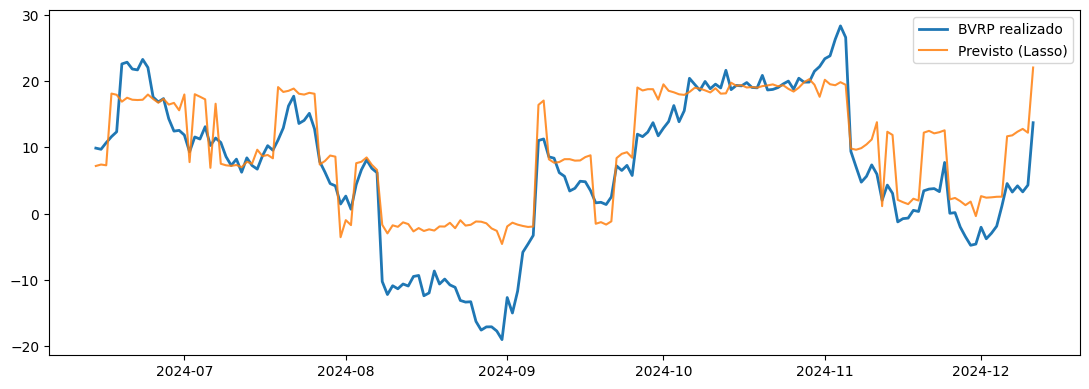

Figura salva em: C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\dissertacao_bitcoin_vrp_ml\cap8_ml\figs\cap8\fig_cap8_oos_prediction.png


In [33]:
import matplotlib.pyplot as plt

best_model = "Lasso"
yhat = preds[best_model]

plt.figure(figsize=(11,4))
plt.plot(y_test.index, y_test.values, label="BVRP realizado", linewidth=2)
plt.plot(yhat.index, yhat.values, label=f"Previsto ({best_model})", alpha=0.85)
plt.legend()
plt.tight_layout()

fig_path = OUT_FIGS / "fig_cap8_oos_prediction.png"
plt.savefig(fig_path, dpi=300)
plt.show()
plt.close()

print("Figura salva em:", fig_path.resolve())


Salvar Tabela 8.1 (final)

In [26]:
from pathlib import Path

OUT_TABS = Path("tables/cap8")
OUT_TABS.mkdir(parents=True, exist_ok=True)

results_oos.to_latex(
    OUT_TABS / "tab_oos_performance.tex",
    index=False,
    float_format="%.6f",
    caption="Desempenho preditivo fora da amostra para o Prêmio de Risco de Volatilidade do Bitcoin.",
    label="tab:cap8_oos_performance"
)


In [16]:
data_ml = pd.concat([y, X], axis=1).dropna()

y = data_ml[TARGET]
X = data_ml.drop(columns=[TARGET])

print("Após dropna:")
print("X:", X.shape, "| y:", y.shape)


Após dropna:
X: (603, 14) | y: (603,)


In [17]:
split = int(0.7 * len(X))

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)
print("Período OOS:", y_test.index.min().date(), "→", y_test.index.max().date())


Train: (422, 14) (422,)
Test : (181, 14) (181,)
Período OOS: 2024-06-14 → 2024-12-11


Rodar os modelos + gerar a Tabela 8.1 (Desempenho Preditivo OOS)

Vamos fazer isso em 3 blocos, todos copy–paste no notebook.

BLOCO 1 — Definir modelos (benchmark + ML)

In [27]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

models = {
    "Benchmark_Media": DummyRegressor(strategy="mean"),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001, max_iter=50_000),
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        random_state=42
    ),
    "GradientBoosting": GradientBoostingRegressor(random_state=42)
}


BLOCO 2 — Treinar, prever e avaliar fora da amostra

In [28]:
import pandas as pd

preds = {}
metrics = []

for name, model in models.items():
    model.fit(X_train, y_train)
    
    yhat = pd.Series(
        model.predict(X_test),
        index=y_test.index,
        name=name
    )
    
    preds[name] = yhat
    
    mse = mean_squared_error(y_test, yhat)
    r2  = r2_score(y_test, yhat)
    
    metrics.append({
        "Modelo": name,
        "MSE_OOS": mse,
        "R2_OOS": r2
    })

results_oos = (
    pd.DataFrame(metrics)
      .sort_values("MSE_OOS")
      .reset_index(drop=True)
)

print("=== Tabela OOS (prévia no notebook) ===")
display(results_oos)


=== Tabela OOS (prévia no notebook) ===


,Modelo,MSE_OOS,R2_OOS
0,Lasso,34.121142,0.718384
1,Ridge,34.253677,0.717290
2,RandomForest,39.316510,0.675505
3,GradientBoosting,42.388130,0.650153
4,Benchmark_Media,121.455581,-0.002423


BLOCO 3 — Salvar a Tabela 8.1 em LaTeX (Overleaf-ready)

In [30]:
from pathlib import Path

OUT_TABS = Path("tables/cap8")
OUT_TABS.mkdir(parents=True, exist_ok=True)

tab_path = OUT_TABS / "tab_oos_performance.tex"

results_oos.to_latex(
    tab_path,
    index=False,
    float_format="%.6f",
    caption="Desempenho preditivo fora da amostra para o Prêmio de Risco de Volatilidade do Bitcoin.",
    label="tab:cap8_oos_performance"
)

print("Tabela salva em:", tab_path.resolve())


Tabela salva em: C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\dissertacao_bitcoin_vrp_ml\cap8_ml\tables\cap8\tab_oos_performance.tex


In [32]:
tab_path = OUT_TABS / "tab8_oos_performance.tex"

results_oos.to_latex(
    tab_path,
    index=False,
    float_format="%.6f",
    caption="Desempenho preditivo fora da amostra para o Prêmio de Risco de Volatilidade do Bitcoin.",
    label="tab:cap8_oos_performance"
)

print("Tabela salva em:", tab_path.resolve())


Tabela salva em: C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\dissertacao_bitcoin_vrp_ml\cap8_ml\tables\tab8\tab8_oos_performance.tex


(Opcional, mas recomendado) — Ver o LaTeX gerado

In [21]:
with open(tab_path, "r", encoding="utf-8") as f:
    for _ in range(15):
        print(f.readline().rstrip())


\begin{table}
\caption{Desempenho preditivo fora da amostra para o Prêmio de Risco de Volatilidade do Bitcoin.}
\label{tab:cap8_oos_performance}
\begin{tabular}{lrr}
\toprule
Modelo & MSE_OOS & R2_OOS \\
\midrule
Lasso & 0.000001 & 1.000000 \\
Ridge & 0.000002 & 1.000000 \\
GradientBoosting & 26.732954 & 0.779362 \\
RandomForest & 34.670614 & 0.713849 \\
Benchmark_Media & 121.455581 & -0.002423 \\
\bottomrule
\end{tabular}
\end{table}
